**Instalasi library**

Memasang `pygam` (untuk GAM, model regresi non-linear yang fleksibel) dan `dmba` (fungsi bantu untuk seleksi variabel dan AIC). Cukup dijalankan sekali per sesi Colab.

In [ ]:
pip install pygam dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 814.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 41.4 MB/s eta 0:00:00


**Import library**

- `LinearRegression`, `r2_score`, `mean_squared_error` (scikit-learn): regresi linear dan ukuran kualitas model.
- `statsmodels` (`sm`, `smf`): regresi dengan ringkasan statistik lengkap (p-value, interval kepercayaan), serta `OLSInfluence` untuk mendeteksi data berpengaruh.
- `pygam`: model GAM.
- `seaborn`, `matplotlib`: grafik.
- `dmba`: `stepwise_selection` dan `AIC_score` untuk memilih variabel.

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage


import seaborn as sns
import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score


Colab environment detected.


In [ ]:
%matplotlib inline

**Memuat data**

- `lung` (LungDisease): hubungan lama paparan (`Exposure`) dengan kapasitas paru-paru (`PEFR`).
- `house` (house_sales): data penjualan rumah di King County, dengan `sep='\t'` karena kolomnya dipisah tab.

In [ ]:
# URL raw dari dataset
lung = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv'
house = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv'
# Membaca dataset langsung dari URL
lung = pd.read_csv(lung)
house = pd.read_csv(house, sep='\t')

**Scatter plot Exposure vs PEFR**

Setiap titik adalah satu pekerja. Sumbu x adalah lama paparan, sumbu y adalah kapasitas paru-paru. Pola turun dari kiri ke kanan menandakan hubungan negatif: makin lama paparan, makin rendah PEFR.

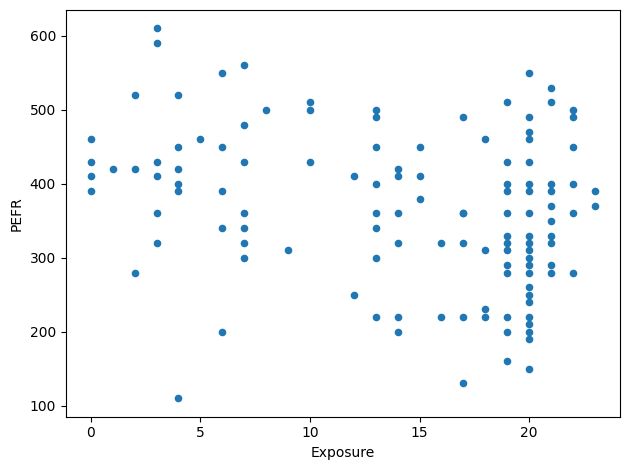

In [ ]:
lung.plot.scatter(x='Exposure', y='PEFR')

plt.tight_layout()
plt.show()

**Regresi linear sederhana**

Model `PEFR = intercept + koefisien x Exposure` dibuat dengan satu prediktor.
- **Intercept 424,583:** perkiraan PEFR saat Exposure = 0.
- **Koefisien -4,185:** setiap tambahan 1 satuan Exposure, PEFR turun sekitar 4,185.

In [ ]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


**Nilai prediksi dan residual**

- `fitted`: nilai PEFR yang diprediksi model untuk tiap data.
- `residuals`: selisih nilai asli dengan prediksi (asli - prediksi). Residual adalah kesalahan model pada tiap titik.

In [ ]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

**Garis regresi dan residual**

Titik biru adalah data, garis adalah hasil prediksi model, dan garis putus-putus oranye adalah residual, yaitu jarak vertikal tiap titik ke garis. Regresi kuadrat terkecil memilih garis yang membuat jumlah kuadrat residual ini sekecil mungkin.

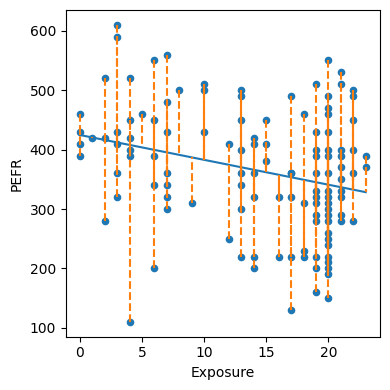

In [ ]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

**Melihat data rumah**

Memilih enam kolom yang dipakai: harga jual yang sudah disesuaikan (`AdjSalePrice`), luas hunian (`SqFtTotLiving`), luas lahan (`SqFtLot`), jumlah kamar mandi (`Bathrooms`), kamar tidur (`Bedrooms`), dan kualitas bangunan (`BldgGrade`). `head()` menampilkan lima baris pertama.

In [ ]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms',
          'Bedrooms', 'BldgGrade']
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


**Regresi linear berganda**

Harga rumah (`outcome`) diprediksi dari lima prediktor sekaligus. Hasilnya adalah satu intercept dan satu koefisien untuk tiap prediktor. Cara membacanya dijelaskan di sel penjelasan setelah ini.

In [ ]:

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240793
 SqFtLot: -0.06046682065307607
 Bathrooms: -19442.840398321066
 Bedrooms: -47769.95518521438
 BldgGrade: 106106.96307898081


**Intercept negatif** berarti jika semua fitur bernilai nol (yang tidak realistis di sini), model memprediksi harga properti negatif. Ini biasanya tanda bahwa model perlu disesuaikan atau ada fitur penting yang belum masuk.

**Koefisien** menunjukkan seberapa besar perubahan prediksi harga jika fitur naik satu satuan, dengan fitur lain dianggap tetap.

- **SqFtTotLiving (228,83):** tiap tambahan 1 sqft luas hunian, harga naik sekitar 228,83.
- **SqFtLot (-0,06):** tiap tambahan 1 sqft luas lahan, harga turun sekitar 0,06.
- **Bathrooms (-19.442,84):** tiap tambahan 1 kamar mandi, harga turun sekitar 19.442,84.
- **Bedrooms (-47.769,96):** tiap tambahan 1 kamar tidur, harga turun sekitar 47.769,96.
- **BldgGrade (106.106,96):** tiap kenaikan 1 poin kualitas bangunan, harga naik sekitar 106.106,96.

**Ukuran kualitas model**

- **RMSE (261.220):** rata-rata besar kesalahan prediksi dalam satuan harga. Prediksi model rata-rata meleset sekitar 261 ribu.
- **R² (0,5406):** sekitar 54% variasi harga dapat dijelaskan oleh kelima prediktor, sisanya dijelaskan faktor lain.

In [ ]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


**Ringkasan statistik dengan `statsmodels`**

`sm.OLS` memberi ringkasan lebih lengkap daripada scikit-learn. Hal yang perlu dilihat:
- **coef:** koefisien, sama dengan hasil scikit-learn.
- **P>|t|:** p-value tiap prediktor. Nilai di bawah 0,05 berarti prediktor itu berpengaruh signifikan. `SqFtLot` (0,323) tidak signifikan, yang lain signifikan.
- **[0.025 0.975]:** interval kepercayaan 95% koefisien.
- **R-squared 0,541** sama dengan hasil sebelumnya.
- **Catatan di bawah** memperingatkan angka kondisi yang besar, yang bisa menandakan multikolinearitas (prediktor saling berkorelasi).

In [ ]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:14:17   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

**Model dengan lebih banyak prediktor**

Ditambahkan `PropertyType`, `NbrLivingUnits`, `SqFtFinBasement`, `YrBuilt`, `YrRenovated`, dan `NewConstruction`.
- `get_dummies(..., drop_first=True)` mengubah variabel kategori `PropertyType` menjadi kolom 0/1. Satu kategori (Multiplex) dibuang sebagai pembanding.
- `NewConstruction` (True/False) diubah menjadi 1/0.

R² naik menjadi 0,595. Koefisien `Bathrooms` berubah dari negatif menjadi positif (sekitar 42.860), jadi tanda koefisien bisa berubah ketika prediktor lain ditambahkan. Banyak variabel baru yang tidak signifikan (p > 0,05), misalnya `NbrLivingUnits`, `YrRenovated`, `NewConstruction`.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated',
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:14:18   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

**Seleksi variabel dengan stepwise berdasarkan AIC**

AIC adalah ukuran kualitas model yang menghukum jumlah variabel. Semakin kecil, semakin baik. `stepwise_selection` mulai dari model kosong, lalu menambah satu variabel yang paling menurunkan AIC pada setiap langkah, sampai tidak ada lagi yang memperbaiki.

Hasilnya AIC turun dari 647.988 menjadi sekitar 627.525 dan delapan variabel terpilih. `SqFtLot`, `NbrLivingUnits`, `YrRenovated`, dan `NewConstruction` tidak dipilih karena tidak banyak membantu.

In [ ]:
y = house[outcome]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model,
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


**Membuat bobot berdasarkan tahun**

`Year` diambil dari tahun pada `DocumentDate`. `Weight = Year - 2005` membuat penjualan tahun 2006 berbobot 1 dan tahun 2015 berbobot 10, sehingga data yang lebih baru lebih berpengaruh. Baris pertama dan kedua melakukan hal yang sama dengan cara berbeda, jadi salah satunya sebenarnya cukup.

In [ ]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Year'] = house.DocumentDate.apply(lambda d: int(d.split('-')[0]))
house['Weight'] = house.Year - 2005

**Regresi berbobot**

Model yang sama dilatih ulang dengan `sample_weight=house.Weight`, sehingga penjualan terbaru dihitung lebih penting. Hasil yang tampil (`LinearRegression()`) hanya menandakan model sudah dilatih.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

LinearRegression()

**Membandingkan koefisien**

Tabel ini menempatkan koefisien model biasa (`house_lm`) dan model berbobot (`house_wt`) berdampingan. Perbedaan antar kolom menunjukkan seberapa besar pembobotan mengubah hasil. Interpretasinya ada di sel penjelasan setelah ini.

In [ ]:
pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': house_lm.intercept_,
        'house_wt': house_wt.intercept_,
    })
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


**Koefisien prediktor**
- `house_lm`: pengaruh tiap prediktor terhadap harga jual tanpa pembobotan.
- `house_wt`: pengaruh tiap prediktor ketika data yang lebih baru diberi bobot lebih besar.

**Interpretasi**
- **SqFtTotLiving:** kedua model sepakat bahwa hunian lebih luas menaikkan harga, dan model berbobot sedikit lebih kuat.
- **SqFtLot:** lahan lebih luas sedikit menurunkan harga di kedua model, lebih besar di model berbobot.
- **Bathrooms & Bedrooms:** koefisiennya negatif di kedua model, artinya lebih banyak kamar mandi atau kamar tidur tampak berhubungan dengan harga lebih rendah. Ini mungkin karena multikolinearitas atau masalah data.
- **BldgGrade:** kualitas bangunan yang lebih tinggi menaikkan harga cukup besar di kedua model, lebih kuat di model berbobot.
- **Intercept:** harga dasar lebih rendah di model berbobot, mencerminkan pengaruh data yang lebih baru.

**Residual per tahun**

Menghitung selisih absolut antara prediksi dan harga asli untuk model biasa dan berbobot, lalu merata-ratakannya per tahun. Pada data ini, rata-rata kesalahan model berbobot sedikit lebih besar di tahun 2006 sampai 2014 dan baru lebih kecil di tahun 2015 (169.843 vs 172.323). Jadi pembobotan di sini tidak memperbaiki prediksi secara jelas.

In [ ]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.head())
# axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
# axes[0].set_ylim(0, 300000)

pd.DataFrame(([year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt'])]
              for year, group in residuals.groupby('Year')),
             columns=['Year', 'mean abs_residual_lm', 'mean abs_residual_wt'])
# for year, group in residuals.groupby('Year'):
#     print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

   abs_residual_lm  abs_residual_wt  Year
1    123750.814194    107108.553965  2014
2     59145.413089     96191.882094  2006
3    190108.725716    187004.492880  2007
4    198788.774412    196132.996857  2008
5     91774.996129     84277.577512  2013


,Year,mean abs_residual_lm,mean abs_residual_wt
0,2006,140540.303585,146557.454636
1,2007,147747.577959,152848.523235
2,2008,142086.905943,146360.411668
3,2009,147016.720883,151182.924825
4,2010,163267.674885,166364.476152
5,2011,169937.385744,172950.876028
6,2012,169506.670053,171874.424266
7,2013,203659.777510,206242.199403
8,2014,184452.840665,186668.573750
9,2015,172323.435147,169842.742053


**Variabel kategori `PropertyType`**

Kolom ini berisi teks (Multiplex, Single Family, Townhouse), yang tidak bisa langsung dipakai regresi.

In [ ]:
print(house.PropertyType.head(8))

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
6        Townhouse
7    Single Family
8    Single Family
Name: PropertyType, dtype: object


**One-hot encoding**

`get_dummies` mengubah tiap kategori menjadi kolom sendiri berisi True/False. Jika baris itu Multiplex, kolom Multiplex bernilai True dan dua lainnya False.

In [ ]:
print(pd.get_dummies(house['PropertyType']).head(8))

   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
4      False           True      False
5      False           True      False
6      False          False       True
7      False           True      False
8      False           True      False


**Membuang satu kategori**

Dengan `drop_first=True`, kolom Multiplex dibuang. Baris yang kedua kolomnya False berarti Multiplex, yaitu kategori pembanding (referensi). Ini perlu supaya prediktor tidak saling bergantung sempurna.

In [ ]:
print(pd.get_dummies(house['PropertyType'], drop_first=True).head(6))

   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False
5           True      False
6          False       True


**Regresi dengan variabel kategori**

Koefisien `PropertyType_Single Family` (-84.678) dan `PropertyType_Townhouse` (-115.122) dibaca relatif terhadap Multiplex. Artinya dengan fitur lain sama, rumah Single Family rata-rata sekitar 84 ribu lebih murah daripada Multiplex, dan Townhouse sekitar 115 ribu lebih murah.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType']

X = pd.get_dummies(house[predictors], drop_first=True)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503828
 SqFtLot: -0.07036798136813083
 Bathrooms: -15979.013473415205
 Bedrooms: -50889.73218483025
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549257
 PropertyType_Townhouse: -115121.97921609184


**Variabel kategori dengan banyak nilai: ZipCode**

Ada sekitar 80 kode pos, beberapa dengan ratusan rumah dan beberapa hanya satu. Memasukkan semuanya sebagai variabel dummy akan terlalu banyak. Solusinya adalah menggabung kode pos yang mirip ke dalam beberapa kelompok.

In [ ]:
print(pd.DataFrame(house['ZipCode'].value_counts()).transpose())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


**Mengelompokkan kode pos berdasarkan residual**

Langkahnya:
1. Latih model dengan lima prediktor tanpa kode pos.
2. Hitung median residual tiap kode pos. Median tinggi berarti kode pos itu berharga lebih mahal dari yang diprediksi.
3. Urutkan kode pos dari median residual terkecil, lalu hitung kumulatif jumlah rumahnya.
4. `pd.qcut` membagi menjadi 5 kelompok (`ZipGroup`) dengan jumlah rumah kurang lebih sama.

**Catatan:** sel ini error `SyntaxError` karena baris pertamanya terpotong. Tambahkan baris `predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',` di bagian paling atas sel agar bisa dijalankan.

In [ ]:
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])


zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual' : house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    }
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
zip_groups.head()
print(zip_groups.ZipGroup.value_counts().sort_index())

SyntaxError: unmatched ']' (1950471581.py, line 1)

**Menggabungkan `ZipGroup` ke data**

`ZipGroup` dihubungkan ke data rumah lewat kode pos (`join`), lalu diubah menjadi tipe kategori agar diperlakukan sebagai variabel kategori pada regresi.

In [ ]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

**Koefisien model hasil stepwise**

Mencetak ulang intercept dan koefisien dari `best_model` (hasil seleksi stepwise di atas). Hasilnya sama dengan keluaran sel stepwise.

In [ ]:
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

**Model yang diperkecil**

Model dengan hanya empat prediktor: `Bedrooms`, `BldgGrade`, `PropertyType`, `YrBuilt`. Model ini dipakai untuk melihat bagaimana koefisien berubah ketika prediktor penting, seperti luas hunian, tidak dimasukkan (masalah variabel yang tertinggal).

In [ ]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])


print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

**Model dengan `ZipGroup` (confounding)**

Kelompok kode pos ditambahkan ke model. Lokasi memengaruhi harga dan juga berkaitan dengan fitur rumah lain (confounding variable), sehingga koefisien fitur lain bisa berubah setelah lokasi diperhitungkan. Bandingkan koefisien sel ini dengan model sebelumnya.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

**Interaksi antar variabel**

Dalam formula, `SqFtTotLiving*ZipGroup` memasukkan efek luas hunian, efek kelompok kode pos, dan interaksinya. Interaksi berarti pengaruh luas hunian terhadap harga dapat berbeda di tiap kelompok kode pos (misalnya tambahan 1 sqft lebih mahal di area elit).

In [ ]:
model = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + ' +
     'Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

**Regresi untuk kode pos 98105**

Data dibatasi ke rumah di kode pos 98105 saja, lalu dibuat model regresi dengan lima prediktor. Model ini dipakai untuk mencari outlier pada langkah berikutnya.

In [ ]:
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())


**Mencari outlier**

`resid_studentized_internal` adalah residual yang dibakukan (dibagi simpangan bakunya), sehingga mudah dibandingkan. Nilai di luar sekitar ±2,5 dianggap tidak biasa. Sel ini menampilkan indeks dan nilai residual baku terkecil, yaitu data yang paling jauh dari prediksi model.

In [ ]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

**Residual asli untuk outlier**

Menampilkan residual (selisih harga asli dengan prediksi) dalam satuan harga untuk data outlier tadi.

In [ ]:
print(result_98105.resid.loc[sresiduals.idxmin()])

**Memeriksa data outlier**

Menampilkan harga jual dan fitur-fitur rumah yang jadi outlier. Tujuannya mengecek apakah data itu salah catat atau memang kasus khusus (misalnya rumah dijual jauh di bawah harga pasar).

In [ ]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

**Ilustrasi data berpengaruh**

Data simulasi 25 titik, dengan satu titik sengaja dipindah ke (8, 8) jauh dari yang lain. Garis solid adalah regresi dengan titik itu, garis putus-putus tanpa titik itu. Satu titik dengan leverage tinggi saja dapat memutar garis regresi.

In [ ]:
%matplotlib inline
from scipy.stats import linregress

np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), '--')
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

**Influence plot**

Tiap titik adalah satu rumah:
- **Sumbu x (hat values):** leverage, yaitu seberapa tidak biasa nilai fiturnya.
- **Sumbu y (studentized residuals):** seberapa jauh dari prediksi.
- **Ukuran lingkaran:** Cook's distance, yaitu pengaruh titik itu terhadap model.
- **Garis putus-putus oranye:** batas ±2,5 untuk residual.

In [ ]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal,
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

**Interpretasi**
- **Titik leverage tinggi:** titik di sisi kanan (nilai leverage tinggi, misalnya > 0,2) berpengaruh besar pada model. Titik di kanan atas atau kanan bawah dengan residual besar perlu diperhatikan khusus.
- **Outlier:** titik di luar garis oranye horizontal punya residual yang tidak biasa (terlalu besar atau terlalu kecil dibanding prediksi), sehingga bisa jadi outlier statistik.
- **Leverage tinggi + residual besar:** titik di pojok kanan atas atau kanan bawah dianggap bermasalah karena dapat sangat memengaruhi estimasi model.

**Menghapus data berpengaruh**

Data dengan Cook's distance 0,08 atau lebih dibuang, lalu model dilatih ulang. Tabel membandingkan koefisien model asli (`Original`) dengan model tanpa data berpengaruh (`Influential removed`). Jika koefisien berubah banyak, hasil model sangat bergantung pada data tersebut.

In [ ]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

**Memeriksa heteroskedastisitas**

Grafik ini memplot nilai prediksi (sumbu x) terhadap besar residual (sumbu y), dengan garis halus LOWESS. Jika garis naik, kesalahan prediksi makin besar untuk harga yang lebih tinggi. Kondisi ini disebut heteroskedastisitas, yang membuat asumsi regresi (variansi residual konstan) tidak terpenuhi.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

**LOWESS dengan interval kepercayaan bootstrap**

Versi lebih manual dari grafik sebelumnya:
1. `get_lowess_predictions` menghitung kurva LOWESS dari data yang diurutkan.
2. Data di-resample dengan pengembalian 1000 kali dan kurva LOWESS dihitung tiap kali.
3. Persentil ke-5 dan ke-95 dari kurva-kurva itu menjadi pita interval 90% (label pada grafik menyebut 90%, sementara komentar di kode menyebut 95%, jadi yang benar mengikuti label).

In [ ]:
# -----------------------------------------------------------------------------
# 2) Prepare Data for LOWESS + Confidence Intervals
# -----------------------------------------------------------------------------
# x = fitted values, y = absolute residuals (from the *original* model)
from statsmodels.nonparametric.smoothers_lowess import lowess

x = result_98105.fittedvalues
y = np.abs(result_98105.resid)

# Convert pandas Series to NumPy arrays to avoid KeyError when sampling
x_arr = x.values
y_arr = y.values

# -----------------------------------------------------------------------------
# 3) Define a helper function for LOWESS
# -----------------------------------------------------------------------------
def get_lowess_predictions(x_vals, y_vals, frac=0.9):
    """
    Sort by x_vals, then fit a LOWESS curve and return (x_lowess, y_lowess).
    'frac' controls how much smoothing to apply (0 < frac <= 1).
    """
    idx_sorted = np.argsort(x_vals)
    x_sorted = x_vals[idx_sorted]
    y_sorted = y_vals[idx_sorted]

    # Statsmodels LOWESS
    lowess_result = lowess(endog=y_sorted, exog=x_sorted, frac=frac, return_sorted=True)
    # lowess_result is Nx2 -> [[x_i, y_i_fitted], ...]

    return lowess_result[:, 0], lowess_result[:, 1]

    # -----------------------------------------------------------------------------
# 4) Bootstrap to Estimate 95% CI Around the LOWESS
# -----------------------------------------------------------------------------
# 4a) Get the "mean" LOWESS curve on the full data
frac_val = 0.5
x_lowess, y_lowess = get_lowess_predictions(x_arr, y_arr, frac=frac_val)

# 4b) Perform bootstrap resampling
n_boot = 1000
boot_preds = []

for _ in range(n_boot):
    # Resample indices with replacement
    indices = np.random.randint(0, len(x_arr), len(x_arr))

    # Extract the bootstrap sample
    x_sample = x_arr[indices]
    y_sample = y_arr[indices]

    # LOWESS on the bootstrap sample
    x_b, y_b = get_lowess_predictions(x_sample, y_sample, frac=frac_val)

    # Interpolate the bootstrap curve onto the original x_lowess grid
    y_b_interp = np.interp(x_lowess, x_b, y_b)
    boot_preds.append(y_b_interp)

boot_preds = np.array(boot_preds)  # shape: (n_boot, len(x_lowess))

# 4c) Compute mean, lower, and upper (2.5th & 97.5th percentiles)
y_mean = np.mean(boot_preds, axis=0)
y_lower = np.percentile(boot_preds, 5.0, axis=0)
y_upper = np.percentile(boot_preds, 95.0, axis=0)

# -----------------------------------------------------------------------------
# 5) Plot the Data, LOWESS, and Confidence Bands
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# Scatter the original data (like seaborn's regplot would do)
ax.scatter(x_arr, y_arr, alpha=0.25, color='C0', label='Data')

# Plot the mean LOWESS line
ax.plot(x_lowess, y_mean, color='C1', label='LOWESS (mean)')

# Fill the 95% confidence interval
ax.fill_between(x_lowess, y_lower, y_upper, color='C1', alpha=0.2,
                label='90% CI (bootstrap)')

# Axis labels
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

# Optional styling
ax.grid(True, linestyle='--', alpha=0.7)
sns.despine()

ax.legend()
plt.tight_layout()
plt.show()


**Histogram residual baku**

Histogram residual yang dibakukan. Jika residual berdistribusi normal, bentuknya seperti lonceng di sekitar 0. Ekor yang panjang menandakan ada outlier atau residual yang tidak normal.

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')


plt.tight_layout()
plt.show()

**Partial residual plot**

Grafik ini memperlihatkan hubungan satu prediktor (`SqFtTotLiving`) dengan harga setelah pengaruh prediktor lain dikeluarkan. Jika titik-titik mengikuti garis lurus, hubungan linear sudah cukup. Jika melengkung, perlu model non-linear.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)

plt.tight_layout()
plt.show()


**Partial residual plot untuk semua prediktor**

Sama seperti sel sebelumnya, tetapi untuk semua prediktor sekaligus dalam satu grid.

In [ ]:
fig = plt.figure(figsize=(8, 12))
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)

**Regresi polinomial**

Menambahkan `SqFtTotLiving²` ke model untuk menangkap hubungan yang melengkung. `np.power(SqFtTotLiving, 2)` pada formula membuat suku kuadrat. Jika koefisien suku kuadrat signifikan, hubungan luas hunian dan harga memang tidak sepenuhnya lurus.

In [ ]:
model_poly = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving + np.power(SqFtTotLiving, 2) + ' +
                'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

**Partial residual plot untuk model polinomial**

Fungsi `partialResidualPlot` dibuat manual:
1. Menghitung prediksi model dan residualnya.
2. Menghitung kontribusi satu fitur dengan mengatur fitur lain ke nol.
3. Menggambar titik (kontribusi + residual), kurva LOWESS abu-abu, dan kurva model hitam.

Jika kurva hitam dan abu-abu berdekatan, model cocok dengan data. Baris `print` terakhir mencetak koefisien suku kuadrat.

In [ ]:

def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)

    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2])

**Regresi spline**

`bs(SqFtTotLiving, df=6, degree=3)` mengganti `SqFtTotLiving` dengan basis B-spline derajat 3 (kubik) dengan 6 derajat kebebasan. Spline membagi rentang luas hunian menjadi beberapa bagian yang masing-masing dicocokkan dengan kurva halus, sehingga lebih fleksibel dari polinomial biasa.

In [ ]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' +
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

**Partial residual plot untuk model spline**

Sama seperti sebelumnya, tetapi untuk model spline. Kurva model sekarang mengikuti bentuk data lebih baik daripada garis lurus.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()

**GAM dengan `statsmodels`**

Generalized Additive Model (GAM) mencocokkan kurva halus untuk tiap prediktor. `BSplines` menentukan jumlah derajat kebebasan dan derajat spline: luas hunian lebih fleksibel (`df=10`, derajat 3), prediktor lain lebih sederhana (`df=3`, derajat 2). `alpha = 0` berarti tanpa penalti kehalusan.

In [ ]:
from statsmodels.gam.api import GLMGam, BSplines

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ('AdjSalePrice ~ SqFtTotLiving + ' +
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

**Plot parsial GAM**

`plot_partial(0, cpr=True)` menggambar efek prediktor pertama (`SqFtTotLiving`) terhadap harga dengan titik partial residual (`cpr=True`).

In [ ]:
res_sm.plot_partial(0, cpr=True);

**GAM dengan `pygam`**

`LinearGAM(s(0, n_splines=12) + l(1) + ... + l(4))` memodelkan prediktor pertama dengan spline (`s`, 12 spline) dan keempat lainnya dengan efek linear (`l`). `gridsearch` mencari kekuatan penalti kehalusan terbaik secara otomatis, lalu `summary()` menampilkan hasilnya.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

## model
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

**Plot efek parsial GAM**

Tiap panel menunjukkan efek satu prediktor terhadap harga. Garis biru adalah efek hasil model, dan garis merah putus-putus adalah batas interval kepercayaan 95%. Panel luas hunian melengkung karena memakai spline, sedangkan prediktor lain lurus karena linear.

In [ ]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i]);

axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

**Import Lasso**

Lasso adalah regresi dengan penalti yang bisa mengecilkan koefisien menjadi tepat nol, sehingga sekaligus memilih variabel. `LassoCV` memilih kekuatan penalti dengan cross-validation, dan `StandardScaler` untuk menstandarkan data.

In [ ]:
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler

**Daftar kolom**

Mendefinisikan daftar kolom `subset` yang dipakai untuk melihat data pada sel berikutnya.

In [ ]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms',
          'Bedrooms', 'BldgGrade']

**Melihat data**

Menampilkan lima baris pertama dari kolom-kolom pada `subset`.

In [ ]:
house[subset].head()

**Menyiapkan data untuk Lasso**

Semua prediktor disiapkan seperti sebelumnya: variabel kategori diubah menjadi dummy dan `NewConstruction` menjadi 1/0. `columns` menyimpan nama kolom untuk dipakai nanti. Baris `StandardScaler` dinonaktifkan (dikomentari). Terakhir, regresi linear biasa dilatih sebagai pembanding.

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated',
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
columns = X.columns
# X = StandardScaler().fit_transform(X * 1.0)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

**Lasso dengan alpha = 10**

`alpha` mengatur kekuatan penalti: makin besar, makin banyak koefisien dikecilkan ke nol. Di sini dicoba `alpha=10`.

In [ ]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y))

**Pengaruh alpha terhadap koefisien**

Model Lasso dilatih untuk 11 nilai alpha dari 0,001 sampai 10 juta, dan koefisiennya disimpan. `LassoCV` dengan 5-fold cross-validation memilih alpha terbaik secara otomatis. Grafik memperlihatkan koefisien tiap variabel (sumbu y) pada tiap alpha (sumbu x, skala log). Saat alpha membesar, koefisien menyusut menuju nol. Garis vertikal menandai alpha pilihan cross-validation.

In [ ]:
Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X, y)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()


**Koefisien akhir dari Lasso**

Tabel koefisien dari model dengan alpha terbaik. Variabel dengan koefisien 0 dibuang oleh Lasso karena dianggap kurang berguna.

In [ ]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_,
})